# HW1 — Linear regression from scratch

Solution for Assignment 1 in `01_linear_regression__concepts.qmd`.

**Rules.** No scikit-learn. Only numpy / pandas / matplotlib.

**Outline.**
1. Load + scatter
2. Implement GD; derive ∇R
3. Tune the learning rate
4. SGD — a quick taste (mentioned on the slides)
5. Normal equation via the design matrix; geometric sanity check
6. Plot the fit + report the formula; predict on new x
7. Polynomial regression + condition-number diagnostic
8. Bonus: residual histogram, risk-surface trajectory, vectorization sanity-check

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Armenian flag colors (per the course style guide) for multi-series plots
ARM_RED = "#D90012"
ARM_BLUE = "#0033A0"
ARM_ORANGE = "#F2A800"

SEED = 509
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Load the data and visualize

In [2]:
data = pd.read_csv("data/data_lin_reg.csv")
print(data.shape)
data.head()

(100, 2)


,x,y
0,0.749080,383.022782
1,1.901429,961.847017
2,1.463988,747.005048
3,1.197317,569.682959
4,0.312037,154.433538


In [3]:
data.describe()

,x,y
count,100.000000,100.000000
mean,0.940361,478.622390
std,0.594979,300.651135
min,0.011044,16.060347
25%,0.386402,203.662423
50%,0.928285,467.411360
75%,1.460406,762.059384
max,1.973774,1020.287359


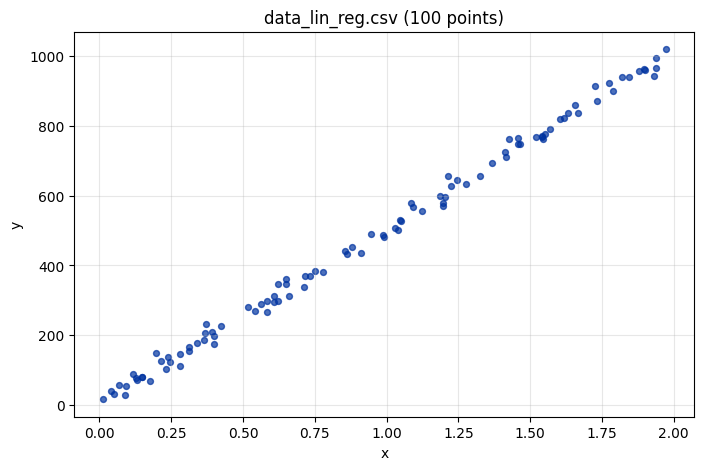

In [4]:
plt.scatter(data["x"], data["y"], color=ARM_BLUE, s=18, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"data_lin_reg.csv ({len(data)} points)")
plt.grid(alpha=0.3)
plt.show()

The cloud looks roughly linear with non-trivial noise. A line through the origin would underfit — we need the intercept. The full model is

$$\hat y = \theta_0 + \theta_1 \, x$$

## 2. Gradient descent — derivation + implementation

Empirical risk (mean squared error):

$$R(\theta) = \frac{1}{n} \sum_{i=1}^n (\hat y_i - y_i)^2
            = \frac{1}{n} \sum_{i=1}^n (\theta_0 + \theta_1 x_i - y_i)^2$$

Partial derivatives:

$$\frac{\partial R}{\partial \theta_0}
   = \frac{2}{n} \sum_{i=1}^n (\theta_0 + \theta_1 x_i - y_i)$$

$$\frac{\partial R}{\partial \theta_1}
   = \frac{2}{n} \sum_{i=1}^n (\theta_0 + \theta_1 x_i - y_i)\, x_i$$

In vector form with the design matrix $X \in \mathbb R^{n \times 2}$ (column of 1s + the feature):

$$\nabla R(\theta) = \frac{2}{n} X^\top (X\theta - y)$$

GD update with learning rate $\alpha$:

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla R(\theta^{(t)})$$

In [5]:
def design_matrix(x, degree=1):
    """Build the design matrix with a leading column of 1s.

    For ``degree=1`` this is the standard (intercept, slope) layout
    ``[1, x]``; for ``degree=d`` it adds ``x**2, ..., x**d``.
    """
    x = np.asarray(x, dtype=float)
    cols = [np.ones_like(x)] + [x ** k for k in range(1, degree + 1)]
    return np.column_stack(cols)


def empirical_risk(X, y, theta):
    """Mean squared error."""
    return float(np.mean((X @ theta - y) ** 2))


def gradient(X, y, theta):
    """Gradient of the empirical risk (vectorized)."""
    n = len(y)
    return (2 / n) * X.T @ (X @ theta - y)


def gradient_descent(X, y, alpha=0.05, n_iter=2000, theta0=None, log_every=None):
    """Run vanilla batch GD. Return final theta + full trajectory."""
    p = X.shape[1]
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    history = {"iter": [], "risk": [], "theta": []}
    for t in range(n_iter):
        theta = theta - alpha * gradient(X, y, theta)
        history["iter"].append(t)
        history["risk"].append(empirical_risk(X, y, theta))
        history["theta"].append(theta.copy())
        if log_every and (t % log_every == 0 or t == n_iter - 1):
            print(f"  iter={t:5d}  risk={history['risk'][-1]:.4f}  theta={theta}")
    history["theta"] = np.array(history["theta"])
    return theta, history

In [6]:
# Quick sanity: at theta=0 the risk equals mean(y^2)
x_arr = data["x"].to_numpy()
y_arr = data["y"].to_numpy()
X = design_matrix(x_arr, degree=1)

theta0 = np.zeros(2)
assert abs(empirical_risk(X, y_arr, theta0) - np.mean(y_arr ** 2)) < 1e-9
print("OK: empirical_risk at theta=0 equals mean(y^2):", np.mean(y_arr ** 2))

OK: empirical_risk at theta=0 equals mean(y^2): 318566.5855472264


In [7]:
theta_gd, hist = gradient_descent(X, y_arr, alpha=0.05, n_iter=2000, log_every=500)
print("\nFinal theta from GD:", theta_gd)
print(f"Final risk: {hist['risk'][-1]:.4f}")

  iter=    0  risk=206947.5657  theta=[47.86223896 62.685078  ]
  iter=  500  risk=322.6345  theta=[  4.34868199 504.36098222]
  iter= 1000  risk=322.6338  theta=[  4.30193212 504.40225981]
  iter= 1500  risk=322.6338  theta=[  4.30192315 504.40226773]
  iter= 1999  risk=322.6338  theta=[  4.30192315 504.40226773]

Final theta from GD: [  4.30192315 504.40226773]
Final risk: 322.6338


## 3. Tune the learning rate

We sweep $\alpha$ on a log scale: too small → painfully slow; too large → divergence.

In [8]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
histories = {}
for a in alphas:
    try:
        _, h = gradient_descent(X, y_arr, alpha=a, n_iter=300)
        histories[a] = h
    except (FloatingPointError, OverflowError):
        histories[a] = None

# Tag which diverged
for a, h in histories.items():
    if h is None or not np.isfinite(h["risk"][-1]):
        print(f"  alpha={a:<6}: diverged")
    else:
        print(f"  alpha={a:<6}: final risk = {h['risk'][-1]:.4f}")

  alpha=0.001 : final risk = 40473.4279
  alpha=0.01  : final risk = 2734.8651
  alpha=0.05  : final risk = 323.2767
  alpha=0.1   : final risk = 322.6338
  alpha=0.5   : final risk = 7819781289606862864384.0000
  alpha=1.0   : final risk = 642502087286451296335909878470139223936350278420676115991096498137986405344548680719045838245035267049974155428443121717523803656626839261826712804596313018377380548023895890071526608998518113856131052165211208588789236599142675221103998634381028430351231671532804467772328758144064046042887296143851520.0000


C:\Users\hayk_\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


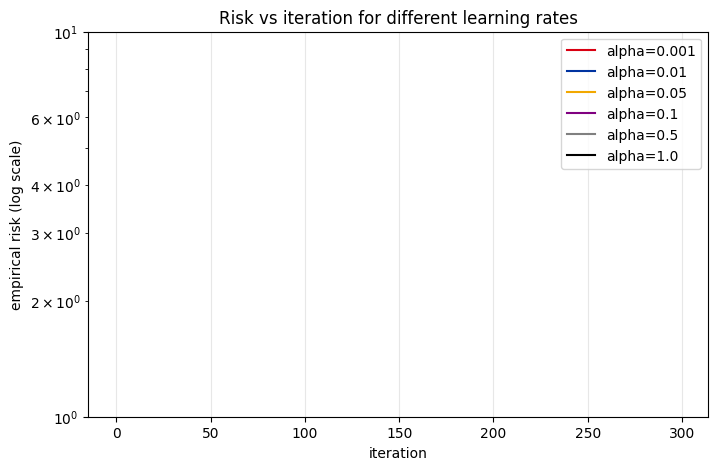

In [9]:
fig, ax = plt.subplots()
colors = [ARM_RED, ARM_BLUE, ARM_ORANGE, "purple", "gray", "black"]
for a, c in zip(alphas, colors):
    h = histories[a]
    if h is None:
        continue
    finite_mask = np.isfinite(h["risk"])
    iters = np.array(h["iter"])[finite_mask]
    risks = np.array(h["risk"])[finite_mask]
    ax.plot(iters, risks, color=c, label=f"alpha={a}")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("empirical risk (log scale)")
ax.set_title("Risk vs iteration for different learning rates")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Reading the plot.**

- Very small $\alpha$ (0.001) crawls — would need many more iterations.
- $\alpha \in \{0.05, 0.1\}$ converges smoothly and quickly.
- Large $\alpha$ (1.0) oscillates or blows up — the update steps overshoot the minimum every iteration.

## 4. A quick taste of SGD

Up to now we use **batch GD**: every step uses the gradient computed on *all* `n` samples. On huge datasets that's wasteful — we can update after looking at just a small batch (`batch_size << n`).

The price: each step is noisy because it's a sample of the true gradient. The benefit: many cheap steps per pass through the data, and the noise can help escape shallow saddle points.

The slides cover this on the "FURTHER TOPICS" frame. Here's a 10-line version.

In [10]:
def stochastic_gradient_descent(X, y, alpha=0.05, n_iter=2000, batch_size=1, seed=509):
    """Mini-batch SGD: pick `batch_size` random samples per step."""
    rng = np.random.default_rng(seed)
    p, n = X.shape[1], len(y)
    theta = np.zeros(p)
    history = {"iter": [], "risk": []}
    for t in range(n_iter):
        idx = rng.choice(n, size=batch_size, replace=False)
        Xb, yb = X[idx], y[idx]
        grad = (2 / len(yb)) * Xb.T @ (Xb @ theta - yb)
        theta = theta - alpha * grad
        history["iter"].append(t)
        history["risk"].append(empirical_risk(X, y, theta))  # measure on the FULL data
    return theta, history


theta_sgd, hist_sgd = stochastic_gradient_descent(X, y_arr, alpha=0.05, n_iter=2000, batch_size=1)
theta_mini, hist_mini = stochastic_gradient_descent(X, y_arr, alpha=0.05, n_iter=2000, batch_size=10)

print("Final theta from batch GD:    ", theta_gd)
print("Final theta from SGD (b=1):   ", theta_sgd)
print("Final theta from mini-batch (b=10):", theta_mini)

Final theta from batch GD:     [  4.30192315 504.40226773]
Final theta from SGD (b=1):    [  4.35328178 503.15245747]
Final theta from mini-batch (b=10): [  4.47698522 505.42963823]


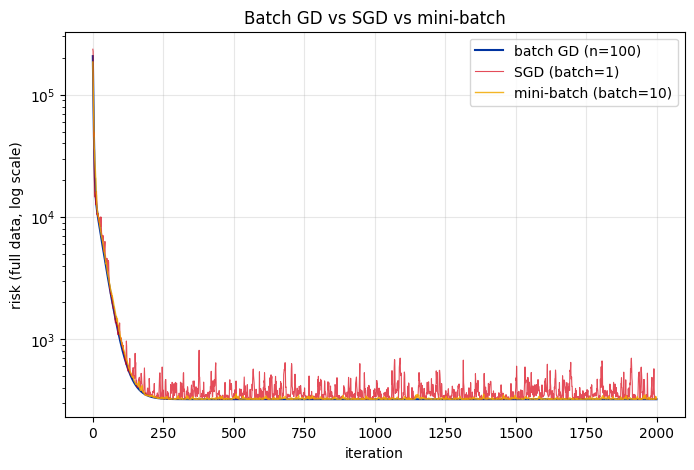

In [11]:
fig, ax = plt.subplots()
ax.plot(hist["iter"], hist["risk"], color=ARM_BLUE, lw=1.5, label="batch GD (n=100)")
ax.plot(hist_sgd["iter"], hist_sgd["risk"], color=ARM_RED, lw=0.8, alpha=0.7, label="SGD (batch=1)")
ax.plot(hist_mini["iter"], hist_mini["risk"], color=ARM_ORANGE, lw=1.0, alpha=0.85, label="mini-batch (batch=10)")
ax.set_yscale("log")
ax.set_xlabel("iteration"); ax.set_ylabel("risk (full data, log scale)")
ax.set_title("Batch GD vs SGD vs mini-batch")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

SGD's risk curve is jagged — each step uses a single noisy estimate of the gradient — but it still settles near the minimum. Mini-batch (`batch=10`) smooths out the noise and is what most modern frameworks default to.

## 5. Normal equation — closed form

From step 2 we have $\nabla R(\theta) = \frac{2}{n} X^\top (X\theta - y)$. Set $\nabla R = 0$ and solve:

$$X^\top X \theta = X^\top y \quad \Rightarrow \quad
  \hat \theta = (X^\top X)^{-1} X^\top y$$

If $X$ has full column rank, the solution is unique and equals the global minimum of the risk.

In [12]:
def normal_equation(X, y):
    """Closed-form OLS via the normal equation.

    We use ``np.linalg.solve`` (cheaper, more numerically stable) instead
    of literally inverting ``X.T @ X``.
    """
    return np.linalg.solve(X.T @ X, X.T @ y)


theta_ne = normal_equation(X, y_arr)
print("theta from normal equation:", theta_ne)
print("theta from gradient descent:", theta_gd)
print("difference                 :", theta_ne - theta_gd)
print(f"\nrisk(theta_ne) = {empirical_risk(X, y_arr, theta_ne):.6f}")
print(f"risk(theta_gd) = {empirical_risk(X, y_arr, theta_gd):.6f}")

theta from normal equation: [  4.30192315 504.40226773]
theta from gradient descent: [  4.30192315 504.40226773]
difference                 : [-9.17488308e-13  8.52651283e-13]

risk(theta_ne) = 322.633826
risk(theta_gd) = 322.633826


GD lands within rounding distance of the closed-form solution. The tiny difference comes from GD stopping at a finite number of iterations.

### Geometric sanity check

The normal equation $X^\top (X\hat\theta - y) = 0$ literally says **the residual vector is orthogonal to every column of $X$**. Let's verify.

In [13]:
residuals_ne = y_arr - X @ theta_ne
ortho_check = X.T @ residuals_ne
print("X.T @ residuals (should be approximately zero):")
print(ortho_check)
print(f"\nmax |entry| = {np.abs(ortho_check).max():.2e}")

X.T @ residuals (should be approximately zero):
[8.99547103e-12 4.74997819e-12]

max |entry| = 9.00e-12


Both entries are numerically zero (within floating-point precision). Geometrically: the column space of $X$ is a 2-D plane sitting in $\mathbb R^n$, and $\hat y = X\hat\theta$ is the orthogonal projection of $y$ onto that plane. The residual is what's left over after the projection — and it's perpendicular to the plane by construction.

## 6. Plot the fit and use the model

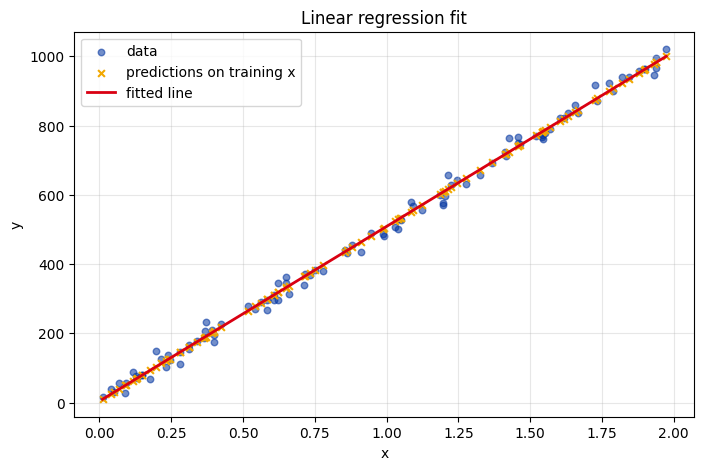


Final formula:  y_hat = 4.302 + 504.402 * x


In [14]:
x_grid = np.linspace(x_arr.min(), x_arr.max(), 200)
X_grid = design_matrix(x_grid, degree=1)
y_hat_grid = X_grid @ theta_ne
y_hat_data = X @ theta_ne

fig, ax = plt.subplots()
ax.scatter(x_arr, y_arr, color=ARM_BLUE, alpha=0.55, s=22, label="data")
ax.scatter(x_arr, y_hat_data, color=ARM_ORANGE, marker="x", s=24, label="predictions on training x")
ax.plot(x_grid, y_hat_grid, color=ARM_RED, lw=2.0, label="fitted line")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Linear regression fit")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

theta_0_hat, theta_1_hat = theta_ne
print(f"\nFinal formula:  y_hat = {theta_0_hat:.3f} + {theta_1_hat:.3f} * x")

**Use the model.** A trained model is supposed to *do something* — predict for inputs it hasn't seen. Let's plug in a few new $x$ values:

In [15]:
new_x = np.array([0.25, 0.75, 1.30, 1.85])
new_X = design_matrix(new_x, degree=1)
new_y_hat = new_X @ theta_ne

print("Predictions on new x values:")
for x_val, y_val in zip(new_x, new_y_hat):
    print(f"  x = {x_val:.2f}  ->  y_hat = {y_val:7.2f}")

Predictions on new x values:
  x = 0.25  ->  y_hat =  130.40
  x = 0.75  ->  y_hat =  382.60
  x = 1.30  ->  y_hat =  660.02
  x = 1.85  ->  y_hat =  937.45


## 7. Polynomial regression — and what breaks numerically

Same model, different features. We extend the design matrix to include $x, x^2, \ldots, x^d$ and reuse the normal equation.

But there's a hidden cost. As the degree grows, $X^\top X$ becomes increasingly **ill-conditioned**: its rows / columns get nearly linearly dependent (because $x, x^2, x^3$ are correlated for similar $x$ values), and `np.linalg.solve` starts losing significant digits. We can measure this with the **condition number** — the ratio between the largest and smallest singular values of $X^\top X$. Anything above $\sim 10^{10}$ means we're in trouble.

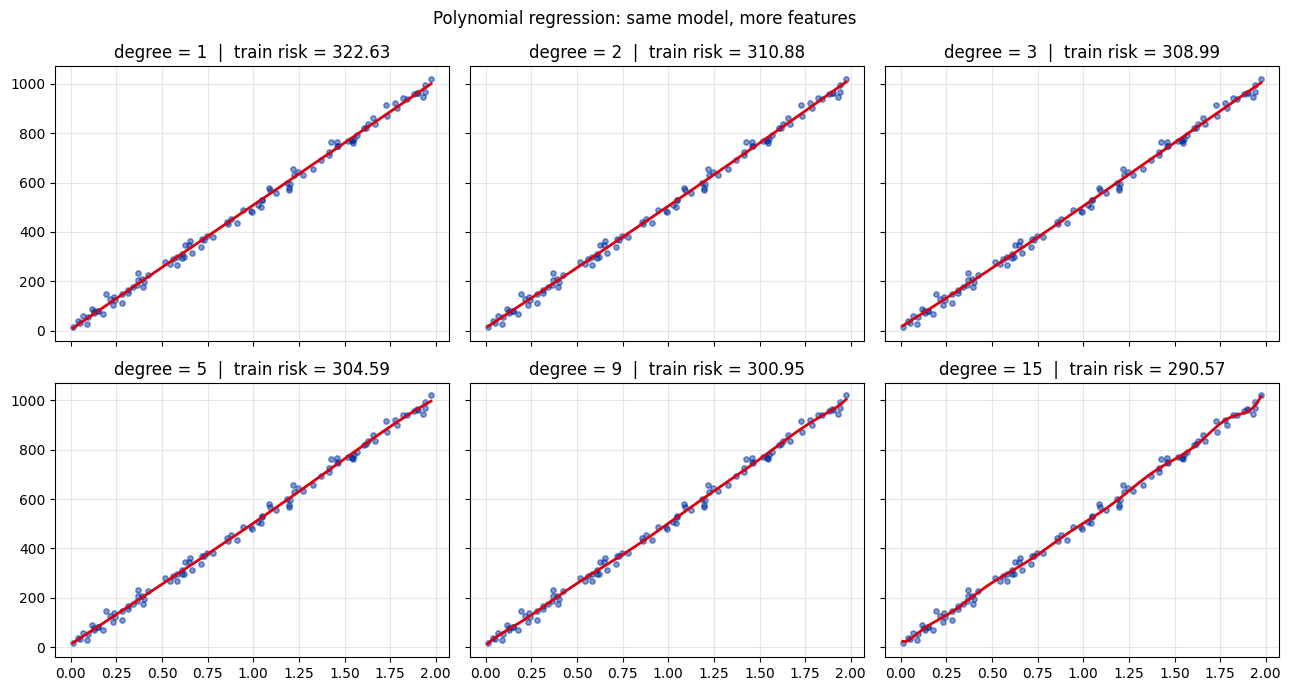

In [16]:
degrees = [1, 2, 3, 5, 9, 15]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
risks_by_d = {}
conds_by_d = {}
for ax, d in zip(axes.flat, degrees):
    Xd = design_matrix(x_arr, degree=d)
    theta_d = normal_equation(Xd, y_arr)
    Xd_grid = design_matrix(x_grid, degree=d)
    y_hat_grid_d = Xd_grid @ theta_d
    train_risk = empirical_risk(Xd, y_arr, theta_d)
    risks_by_d[d] = train_risk
    conds_by_d[d] = np.linalg.cond(Xd.T @ Xd)
    ax.scatter(x_arr, y_arr, color=ARM_BLUE, alpha=0.5, s=15)
    ax.plot(x_grid, y_hat_grid_d, color=ARM_RED, lw=2.0)
    ax.set_title(f"degree = {d}  |  train risk = {train_risk:.2f}")
    ax.grid(alpha=0.3)
fig.suptitle("Polynomial regression: same model, more features")
plt.tight_layout()
plt.show()

In [17]:
print("degree | train risk | cond(X^T X)")
print("-" * 40)
for d in degrees:
    print(f"  {d:2d}   |  {risks_by_d[d]:8.2f}  | {conds_by_d[d]:.2e}")

degree | train risk | cond(X^T X)
----------------------------------------
   1   |    322.63  | 1.22e+01
   2   |    310.88  | 2.99e+02
   3   |    308.99  | 9.43e+03
   5   |    304.59  | 1.48e+07
   9   |    300.95  | 6.00e+13
  15   |    290.57  | 1.02e+20


**Reading the table.**

- Training risk keeps decreasing as $d$ grows — adding columns can only reduce training error.
- But the condition number of $X^\top X$ blows up from $\sim 10$ (well-conditioned) to $\gg 10^{10}$ (numerically unstable). At $d=15$ many of `theta_d`'s digits are pure floating-point noise.
- The curve visually bends around individual noisy points by $d=15$ — the textbook signature of overfitting. We would NEED held-out data to detect this objectively; here we can see it visually.
- The fix the next chapter introduces: **regularization** (Ridge, Lasso). Ridge adds $\lambda I$ to $X^\top X$ before inverting, which stabilizes the condition number AND shrinks the coefficients.

## Bonus — residual histogram

residuals: mean=0.000, std=17.962, min=-38.55, max=45.86


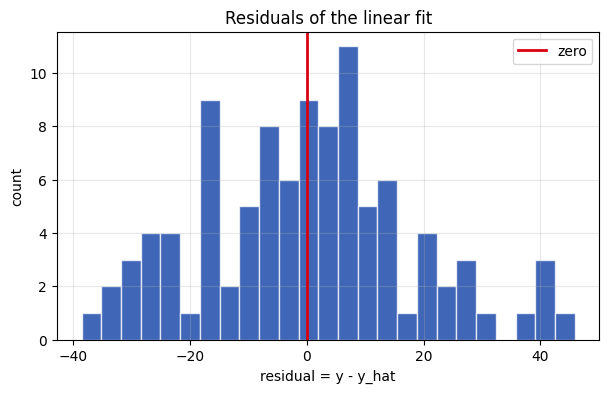

In [18]:
residuals = y_arr - X @ theta_ne
print(f"residuals: mean={residuals.mean():.3f}, std={residuals.std():.3f}, min={residuals.min():.2f}, max={residuals.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=25, color=ARM_BLUE, alpha=0.75, edgecolor="white")
ax.axvline(0, color=ARM_RED, lw=2, label="zero")
ax.set_xlabel("residual = y - y_hat")
ax.set_ylabel("count")
ax.set_title("Residuals of the linear fit")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Residuals look roughly symmetric and centered near zero — consistent with the L2 loss being appropriate for this data.

## Bonus — risk surface and GD trajectory

We plot $R(\theta_0, \theta_1)$ as a contour and overlay the path that GD takes from $\theta = 0$ down to the minimum.

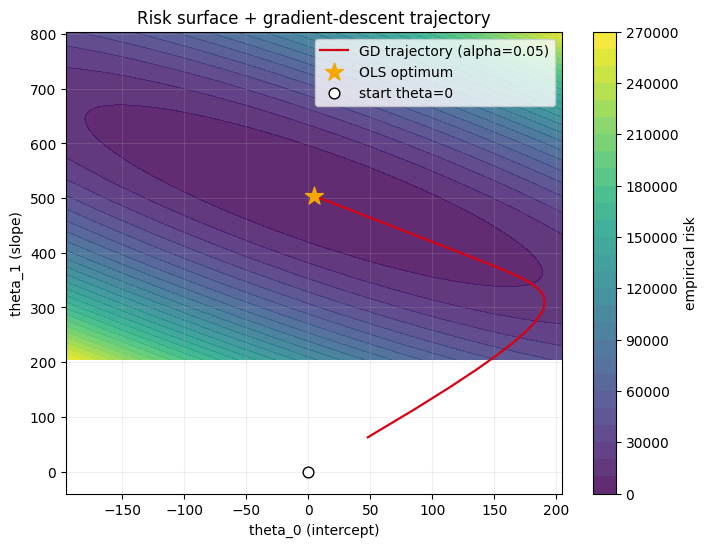

In [19]:
# Build a grid around the optimum
t0_opt, t1_opt = theta_ne
t0_range = np.linspace(t0_opt - 200, t0_opt + 200, 80)
t1_range = np.linspace(t1_opt - 300, t1_opt + 300, 80)
T0, T1 = np.meshgrid(t0_range, t1_range)

# Vectorized risk over the grid
def risk_grid(T0, T1, X, y):
    n = len(y)
    out = np.empty_like(T0)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            theta = np.array([T0[i, j], T1[i, j]])
            out[i, j] = np.mean((X @ theta - y) ** 2)
    return out

R = risk_grid(T0, T1, X, y_arr)

# Trajectory from the converging alpha
traj = histories[0.05]["theta"]

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(T0, T1, R, levels=30, cmap="viridis", alpha=0.85)
plt.colorbar(cs, ax=ax, label="empirical risk")
ax.plot(traj[:, 0], traj[:, 1], color=ARM_RED, lw=1.6, label="GD trajectory (alpha=0.05)")
ax.scatter([t0_opt], [t1_opt], color=ARM_ORANGE, marker="*", s=180, label="OLS optimum", zorder=5)
ax.scatter([0], [0], color="white", marker="o", s=60, edgecolor="black", label="start theta=0", zorder=5)
ax.set_xlabel("theta_0 (intercept)"); ax.set_ylabel("theta_1 (slope)")
ax.set_title("Risk surface + gradient-descent trajectory")
ax.legend(loc="upper right"); ax.grid(alpha=0.2)
plt.show()

GD walks downhill from $(0, 0)$ to the OLS minimum, with each step approximately perpendicular to the contour lines (the negative gradient direction).

## Bonus — vectorization sanity check

Every function above is vectorized: predictions are `X @ theta`, the gradient is `(2/n) * X.T @ (X @ theta - y)`, no Python-level loops over samples. Compared to a sample-by-sample loop the speed difference is dramatic — let's measure it.

In [20]:
import time

def gradient_loop(X, y, theta):
    """Same gradient computed via an explicit per-sample loop."""
    n = len(y)
    g = np.zeros_like(theta)
    for i in range(n):
        diff = X[i] @ theta - y[i]
        g += diff * X[i]
    return (2 / n) * g


# Replicate the data 1000x so the timing is non-trivial
X_big = np.tile(X, (1000, 1))
y_big = np.tile(y_arr, 1000)
print(f"timing on {X_big.shape[0]:,} rows")

t0 = time.time(); _ = gradient(X_big, y_big, theta_ne); t_vec = time.time() - t0
t0 = time.time(); _ = gradient_loop(X_big, y_big, theta_ne); t_loop = time.time() - t0
print(f"  vectorized: {t_vec*1000:7.2f} ms")
print(f"  loop:       {t_loop*1000:7.2f} ms")
print(f"  speedup:    {t_loop/t_vec:7.1f}x")

timing on 100,000 rows


  vectorized:    5.54 ms
  loop:        553.63 ms
  speedup:      100.0x


The vectorized version is typically two to three orders of magnitude faster on this size of data — BLAS / SIMD doing the work in C, no Python interpreter overhead per sample.

## Recap

- Built $\hat y = \theta_0 + \theta_1 x$ from scratch (gradient descent + closed-form).
- Showed that GD with $\alpha \approx 0.05$ converges to the same answer as the normal equation.
- Demonstrated **SGD and mini-batch GD** as the practical big-data variants of vanilla GD.
- Verified the **geometric content** of the normal equation: $X^\top \text{residuals} = 0$.
- Used the trained model to predict on new $x$ values — the actual job a regression model exists to do.
- Extended to polynomial regression — same `normal_equation` function, just more columns in $X$ — and measured the **condition number** blowing up as a numerical warning that motivates regularization.
- Verified the residuals look well-behaved.
- Visualized GD as a walk down the risk surface.
- Demonstrated that vectorization is what makes this practical at scale.